In [64]:
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
code = "19_1_5"
max_col_ops = 100

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True,
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print("Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.")

Loading QECC: 19_1_5
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100)...
Computing initial single faults...

Running lookahead verification stabilizers search for t=2 layers (top_n=50)...

--- X Faults Verification ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 26
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 26

--- Z Faults Verification ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 23
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 23

Synthesizing X fault verification circuits...

Synthesizing Z fault verification circuits...

--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 31
Num CX: 96
Total instructions: 118
Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.


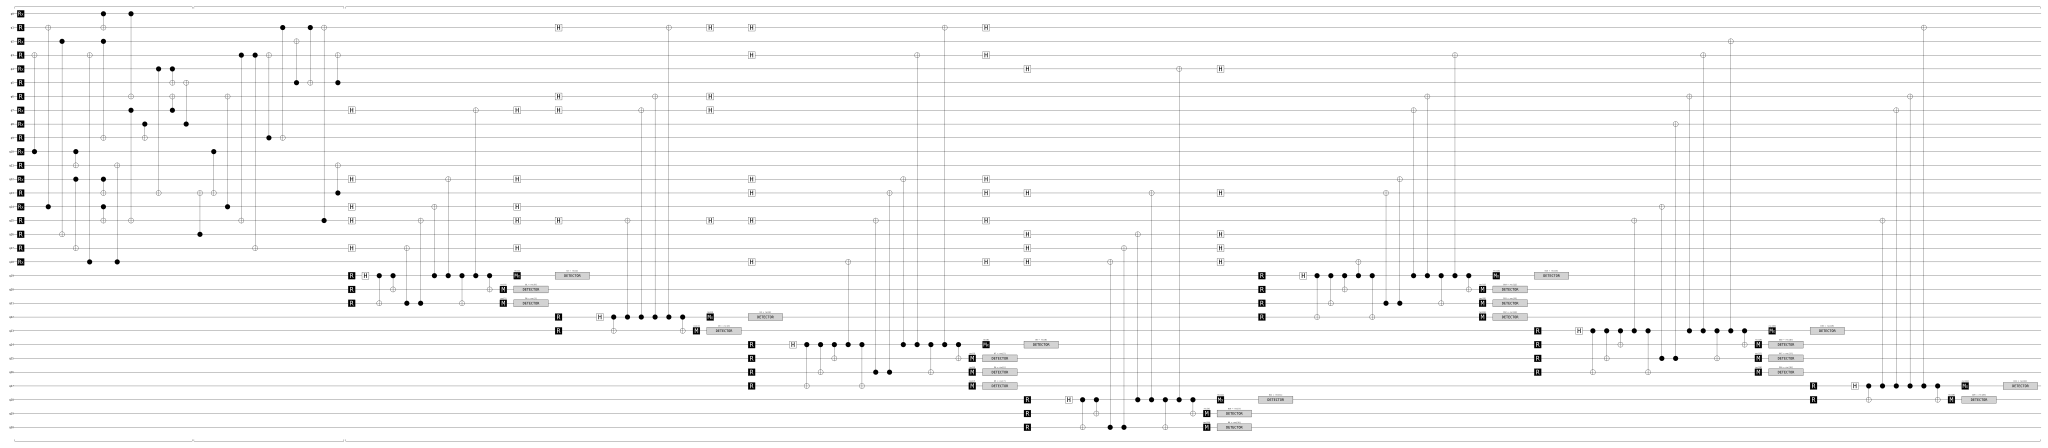

In [70]:
final_circ.diagram('timeline-svg')

In [48]:
final_circ.num_qubits

18

In [49]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_x.T % 2)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
[[1 0]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]]


In [50]:
from spiderstate.optimize_parity_matrix import ancilla_cost

ancilla_cost([[1,1,1,0,0], [0,0,1,1,1], [1, 0, 1, 0, 0]], 4)

1

In [52]:
print(final_circ)

R 0
RX 1
R 2
RX 3 4
R 5
RX 6
R 7 8
RX 9
R 10 11
CX 1 7 6 11 1 8 6 5 9 8 4 5 9 10 4 0 3 0 3 10
TICK
CX 6 2 2 10 1 5 8 11 3 8 0 7 0 6 5 0
TICK
H 0 2 8 9
R 12 13
H 12
CX 12 13 12 9 12 8 12 2 12 0 12 13
M 13
DETECTOR rec[-1]
MX 12
H 0 2 8 9
DETECTOR rec[-1]
H 6 7 8 10
R 14 15
H 14
CX 14 15 14 10 14 8 14 7 14 6 14 15
M 15
DETECTOR rec[-1]
MX 14
H 6 7 8 10
DETECTOR rec[-1]
H 5 7 8 11
R 16 17
H 16
CX 16 17 16 11 16 8 16 7 16 5 16 17
M 17
DETECTOR rec[-1]
MX 16
H 5 7 8 11
DETECTOR rec[-1]
R 12 13
H 12
CX 12 13 12 3 12 2 12 1 12 0 12 13
M 13
DETECTOR rec[-1]
MX 12
DETECTOR rec[-1]
